# Predire l'imprevedibile — Demo introduttiva

**Obiettivo della demo**: mostrare i primi passi operativi del progetto di rilevamento anomalie nel traffico di Bologna.

In questo notebook vediamo solo le fasi preliminari:
1. **Scaricamento** dei dati di traffico (spire Comune di Bologna) e dei dati meteo (Open-Meteo)
2. **Merge** dei due dataset su timestamp
3. **Visualizzazioni di base** per esplorare i dati

> Questa è una demo veloce: lavoriamo su **poche spire** e su un **periodo breve** (un mese) per non appesantire la rete e le elaborazioni.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

# Parametri della demo: periodo breve e poche spire
ANNO = 2024
DATA_INIZIO = '2024-06-01'
DATA_FINE   = '2024-06-30'
N_SPIRE_DEMO = 5    # limitiamo a 5 spire per velocità

# Coordinate Bologna per il meteo
LAT, LON = 44.49, 11.34

print(f'Periodo demo: {DATA_INIZIO} → {DATA_FINE}')
print(f'Numero spire selezionate: {N_SPIRE_DEMO}')

Periodo demo: 2024-06-01 → 2024-06-30
Numero spire selezionate: 5


## 1. Scaricamento dati traffico (spire Comune di Bologna)

I dati sono pubblicati sul portale Open Data del Comune di Bologna. Usiamo l'API Opendatasoft con un filtro `where` sulla data per scaricare solo il periodo che ci interessa.

**Schema del dato grezzo**: ogni riga = una spira in un giorno specifico, con 24 colonne orarie (`00:00-01:00`, `01:00-02:00`, ..., `23:00-24:00`). Faremo un **melt** per portare il dataset in formato *long* (una riga per timestamp orario).

In [2]:
def scarica_spire(anno: int, data_inizio: str, data_fine: str) -> pd.DataFrame:
    """Scarica i flussi orari delle spire di Bologna per un intervallo di date.

    Usiamo l'endpoint /exports/json che non ha limiti di pagina (l'endpoint /records
    standard di Opendatasoft satura a offset=10000).
    """
    dataset_id = f'rilevazione-flusso-veicoli-tramite-spire-anno-{anno}'
    url = f'https://opendata.comune.bologna.it/api/explore/v2.1/catalog/datasets/{dataset_id}/exports/json'
    params = {
        "where": f"data >= '{data_inizio}' AND data <= '{data_fine}'",
    }
    r = requests.get(url, params=params, timeout=120)
    r.raise_for_status()
    return pd.DataFrame(r.json())

# Cache locale: scarichiamo una volta sola
file_spire = DATA_DIR / f'spire_{DATA_INIZIO}_{DATA_FINE}.parquet'
if file_spire.exists():
    df_spire_raw = pd.read_parquet(file_spire)
    print(f'Letto da cache: {file_spire}')
else:
    df_spire_raw = scarica_spire(ANNO, DATA_INIZIO, DATA_FINE)
    df_spire_raw.to_parquet(file_spire)
    print(f'Scaricato e salvato: {file_spire}')

print(f'Shape grezzo: {df_spire_raw.shape}')
df_spire_raw.head(3)


Scaricato e salvato: data\spire_2024-06-01_2024-06-30.parquet
Shape grezzo: (25350, 45)


,data,codice_spira,00_00_01_00,01_00_02_00,02_00_03_00,03_00_04_00,04_00_05_00,05_00_06_00,06_00_07_00,07_00_08_00,...,ordinanza,stato,codimpsem,direzione,angolo,longitudine,latitudine,geopoint,chiave,num_giorno_settimana
0,2024-06-24,3.44 3.47 8 1,25,19,9,6,3,20,40,139,...,4000/343434,A,139,SE,216,11.360612,44.506838,"{'lon': 11.360612084322, 'lat': 44.5068376152542}",620,Lunedì
1,2024-06-24,3.50 1.1 2 2,52,26,11,11,10,39,137,391,...,4000/343434,A,128,O,72,11.355427,44.498493,"{'lon': 11.3554272214055, 'lat': 44.4984932059...",635,Lunedì
2,2024-06-24,4.3 4.48 2 1,263,103,46,23,52,171,505,903,...,4000/343434,A,266,O,97,11.388582,44.493277,"{'lon': 11.3885822096084, 'lat': 44.4932769357...",761,Lunedì


In [3]:
# Diamo un'occhiata alle colonne disponibili
print('Colonne:', list(df_spire_raw.columns))

Colonne: ['data', 'codice_spira', '00_00_01_00', '01_00_02_00', '02_00_03_00', '03_00_04_00', '04_00_05_00', '05_00_06_00', '06_00_07_00', '07_00_08_00', '08_00_09_00', '09_00_10_00', '10_00_11_00', '11_00_12_00', '12_00_13_00', '13_00_14_00', '14_00_15_00', '15_00_16_00', '16_00_17_00', '17_00_18_00', '18_00_19_00', '19_00_20_00', '20_00_21_00', '21_00_22_00', '22_00_23_00', '23_00_24_00', 'id_uni', 'livello', 'tipologia', 'codice', 'codice_arco', 'codice_via', 'nome_via', 'nodo_da', 'nodo_a', 'ordinanza', 'stato', 'codimpsem', 'direzione', 'angolo', 'longitudine', 'latitudine', 'geopoint', 'chiave', 'num_giorno_settimana']


### Selezione di poche spire e melt in formato long

Selezioniamo solo `N_SPIRE_DEMO` spire (quelle con il maggior numero di rilevazioni nel periodo) e portiamo i dati in formato *long*: una riga = `(spira, timestamp orario, conteggio)`.

In [4]:
# 1) Selezione delle top spire nel periodo.
#    Usiamo la 'chiave' (identificativo del sensore) e non solo id_uni, perche'
#    in alcuni casi lo stesso id_uni copre piu sensori distinti (es. due direzioni
#    di marcia sulla stessa stazione): in quei casi selezionare per id_uni produce
#    record duplicati nei merge successivi.
top_spire = (
    df_spire_raw.groupby(['id_uni', 'chiave']).size()
      .sort_values(ascending=False)
      .head(N_SPIRE_DEMO)
      .index.tolist()  # lista di tuple (id_uni, chiave)
)
print('Spire selezionate (id_uni, chiave):', top_spire)

mask = df_spire_raw.set_index(['id_uni', 'chiave']).index.isin(top_spire)
df_sel = df_spire_raw[mask].copy()

# 2) Colonne orarie nel formato HH_00_HH_00
import re
pat = re.compile(r'^\d{2}_\d{2}_\d{2}_\d{2}$')
colonne_orarie = [c for c in df_sel.columns if pat.match(c)]
print(f'Colonne orarie trovate: {len(colonne_orarie)}')

# 3) Melt in formato long
id_vars = ['data', 'id_uni', 'chiave']
for opt in ['nome_via', 'direzione', 'longitudine', 'latitudine']:
    if opt in df_sel.columns:
        id_vars.append(opt)

df_long = df_sel.melt(
    id_vars=id_vars,
    value_vars=colonne_orarie,
    var_name='fascia_oraria',
    value_name='conteggio_veicoli',
)

# 4) Timestamp orario
df_long['ora'] = df_long['fascia_oraria'].str[:2].astype(int)
df_long['timestamp'] = pd.to_datetime(df_long['data']) + pd.to_timedelta(df_long['ora'], unit='h')
df_long['conteggio_veicoli'] = pd.to_numeric(df_long['conteggio_veicoli'], errors='coerce')

df_long = df_long.sort_values(['chiave', 'timestamp']).reset_index(drop=True)
print('')
print(f'Shape dataset long: {df_long.shape}')
df_long[['timestamp', 'id_uni', 'chiave', 'nome_via', 'conteggio_veicoli']].head()


Spire selezionate (id_uni, chiave): [(1, 537), (2, 538), (5, 722), (6, 800), (7, 803)]
Colonne orarie trovate: 24

Shape dataset long: (3600, 11)


,timestamp,id_uni,chiave,nome_via,conteggio_veicoli
0,2024-06-01 00:00:00,1,537,VIA DI CORTICELLA,168
1,2024-06-01 01:00:00,1,537,VIA DI CORTICELLA,125
2,2024-06-01 02:00:00,1,537,VIA DI CORTICELLA,101
3,2024-06-01 03:00:00,1,537,VIA DI CORTICELLA,67
4,2024-06-01 04:00:00,1,537,VIA DI CORTICELLA,77


## 2. Scaricamento dati meteo (Open-Meteo)

Open-Meteo offre un endpoint storico gratuito senza chiave. Scarichiamo temperatura, precipitazioni e velocità del vento orarie per Bologna nello stesso periodo.

In [5]:
def scarica_meteo(lat: float, lon: float, data_inizio: str, data_fine: str) -> pd.DataFrame:
    """Scarica i dati meteo orari da Open-Meteo per una località e un periodo."""
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude': lat,
        'longitude': lon,
        'start_date': data_inizio,
        'end_date': data_fine,
        'hourly': 'temperature_2m,precipitation,rain,wind_speed_10m,weather_code',
        'timezone': 'Europe/Rome',
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    h = r.json()['hourly']
    df = pd.DataFrame(h)
    df['timestamp'] = pd.to_datetime(df['time'])
    return df.drop(columns=['time'])

file_meteo = DATA_DIR / f'meteo_{DATA_INIZIO}_{DATA_FINE}.parquet'
if file_meteo.exists():
    df_meteo = pd.read_parquet(file_meteo)
    print(f'Letto da cache: {file_meteo}')
else:
    df_meteo = scarica_meteo(LAT, LON, DATA_INIZIO, DATA_FINE)
    df_meteo.to_parquet(file_meteo)
    print(f'Scaricato e salvato: {file_meteo}')

print(f'Shape meteo: {df_meteo.shape}')
df_meteo.head()

Scaricato e salvato: data\meteo_2024-06-01_2024-06-30.parquet
Shape meteo: (720, 6)


,temperature_2m,precipitation,rain,wind_speed_10m,weather_code,timestamp
0,14.3,0.0,0.0,13.2,0,2024-06-01 00:00:00
1,14.5,0.0,0.0,13.5,0,2024-06-01 01:00:00
2,13.6,0.0,0.0,15.1,0,2024-06-01 02:00:00
3,12.9,0.0,0.0,12.3,0,2024-06-01 03:00:00
4,13.9,0.0,0.0,13.3,0,2024-06-01 04:00:00


### Tabella di mapping `weather_code` (WMO)

Open-Meteo restituisce un codice numerico WMO. Convertiamolo in etichette qualitative leggibili: utile sia per i grafici sia per chi userà i dati nel resto del progetto.

Riferimento: [WMO Weather interpretation codes](https://open-meteo.com/en/docs/historical-weather-api) (sezione *WMO Weather interpretation codes*).


In [6]:
# Mapping codici WMO -> etichetta qualitativa
WMO_MAP = {
    0:  'Sereno',
    1:  'Prevalentemente sereno',
    2:  'Parzialmente nuvoloso',
    3:  'Coperto',
    45: 'Nebbia',
    48: 'Nebbia con brina',
    51: 'Pioggerella leggera',
    53: 'Pioggerella moderata',
    55: 'Pioggerella intensa',
    56: 'Pioggerella gelata leggera',
    57: 'Pioggerella gelata intensa',
    61: 'Pioggia leggera',
    63: 'Pioggia moderata',
    65: 'Pioggia intensa',
    66: 'Pioggia gelata leggera',
    67: 'Pioggia gelata intensa',
    71: 'Neve leggera',
    73: 'Neve moderata',
    75: 'Neve intensa',
    77: 'Granuli di neve',
    80: 'Rovesci leggeri',
    81: 'Rovesci moderati',
    82: 'Rovesci violenti',
    85: 'Rovesci di neve leggeri',
    86: 'Rovesci di neve intensi',
    95: 'Temporale',
    96: 'Temporale con grandine leggera',
    99: 'Temporale con grandine intensa',
}

df_meteo['tempo'] = df_meteo['weather_code'].map(WMO_MAP).fillna('Sconosciuto')
df_meteo['tempo'].value_counts()


tempo
Sereno                    282
Coperto                   155
Prevalentemente sereno     97
Parzialmente nuvoloso      77
Pioggerella leggera        68
Pioggerella moderata       13
Pioggia moderata           12
Pioggia leggera            10
Pioggia intensa             3
Pioggerella intensa         3
Name: count, dtype: int64

## 3. Merge dei due dataset

Uniamo traffico e meteo sul `timestamp`. Il meteo è uno solo per tutta la città, quindi viene replicato su tutte le spire (left join sul traffico).

In [7]:
df = df_long.merge(df_meteo, on='timestamp', how='left')

# Qualche colonna temporale utile per i grafici
df['giorno_settimana'] = df['timestamp'].dt.day_name()
df['ora_del_giorno']   = df['timestamp'].dt.hour
df['weekend']          = df['timestamp'].dt.dayofweek >= 5

print(f'Shape dataset finale: {df.shape}')
print(f'Periodo: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'Spire (chiavi distinte): {df["chiave"].nunique()}')
df.head()

Shape dataset finale: (3600, 20)
Periodo: 2024-06-01 00:00:00 → 2024-06-30 23:00:00
Spire (chiavi distinte): 5


,data,id_uni,chiave,nome_via,direzione,longitudine,latitudine,fascia_oraria,conteggio_veicoli,ora,timestamp,temperature_2m,precipitation,rain,wind_speed_10m,weather_code,tempo,giorno_settimana,ora_del_giorno,weekend
0,2024-06-01,1,537,VIA DI CORTICELLA,S,11.34857,44.523315,00_00_01_00,168,0,2024-06-01 00:00:00,14.3,0.0,0.0,13.2,0,Sereno,Saturday,0,True
1,2024-06-01,1,537,VIA DI CORTICELLA,S,11.34857,44.523315,01_00_02_00,125,1,2024-06-01 01:00:00,14.5,0.0,0.0,13.5,0,Sereno,Saturday,1,True
2,2024-06-01,1,537,VIA DI CORTICELLA,S,11.34857,44.523315,02_00_03_00,101,2,2024-06-01 02:00:00,13.6,0.0,0.0,15.1,0,Sereno,Saturday,2,True
3,2024-06-01,1,537,VIA DI CORTICELLA,S,11.34857,44.523315,03_00_04_00,67,3,2024-06-01 03:00:00,12.9,0.0,0.0,12.3,0,Sereno,Saturday,3,True
4,2024-06-01,1,537,VIA DI CORTICELLA,S,11.34857,44.523315,04_00_05_00,77,4,2024-06-01 04:00:00,13.9,0.0,0.0,13.3,0,Sereno,Saturday,4,True


## 4. Visualizzazioni di base

Quattro grafici introduttivi per farci un'idea della struttura dei dati.

### 4.1 Serie storica del flusso, una spira

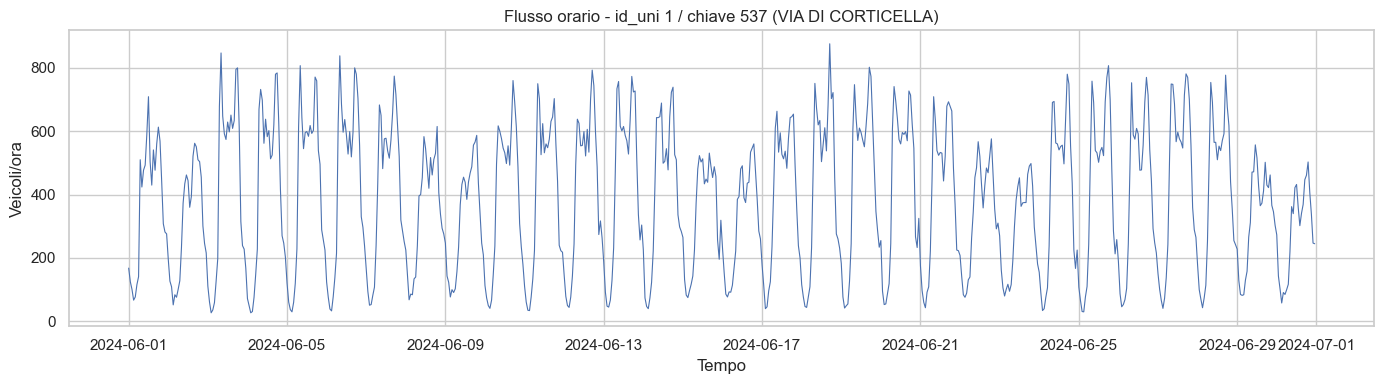

In [8]:
id_uni_demo, chiave_demo = top_spire[0]
df_one = (
    df[(df['id_uni'] == id_uni_demo) & (df['chiave'] == chiave_demo)]
      .sort_values('timestamp')
)
via = df_one['nome_via'].iloc[0] if 'nome_via' in df_one.columns else id_uni_demo

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_one['timestamp'], df_one['conteggio_veicoli'], linewidth=0.8)
ax.set_title(f'Flusso orario - id_uni {id_uni_demo} / chiave {chiave_demo} ({via})')
ax.set_xlabel('Tempo')
ax.set_ylabel('Veicoli/ora')
plt.tight_layout()
plt.show()


### 4.2 Profilo orario medio per giorno della settimana

Il classico pattern feriale (doppia gobba ore di punta) vs. weekend.

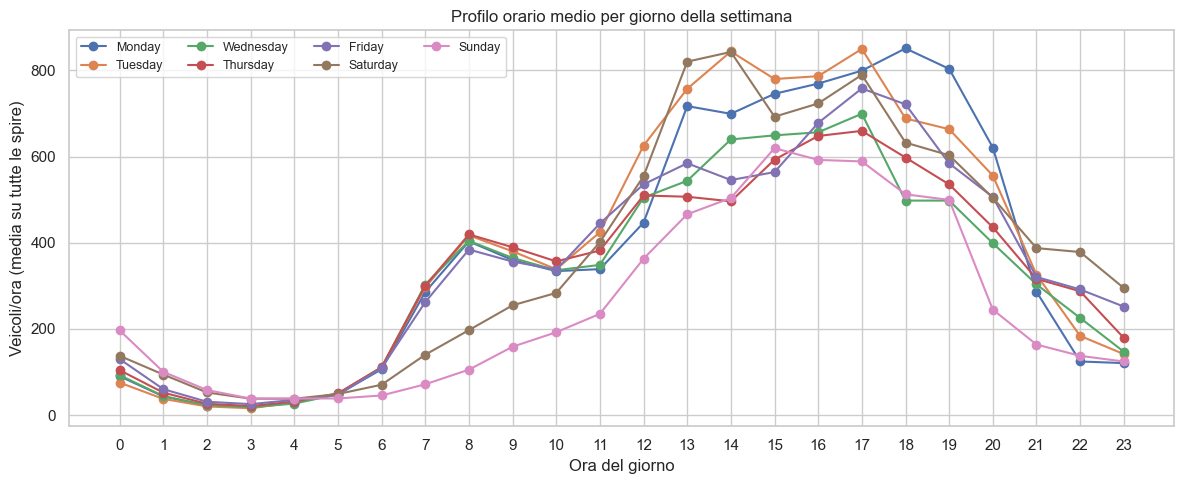

In [9]:
ordine_giorni = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

profilo = (
    df.groupby(['giorno_settimana', 'ora_del_giorno'])['conteggio_veicoli']
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for g in ordine_giorni:
    sub = profilo[profilo['giorno_settimana'] == g]
    ax.plot(sub['ora_del_giorno'], sub['conteggio_veicoli'], marker='o', label=g)
ax.set_title('Profilo orario medio per giorno della settimana')
ax.set_xlabel('Ora del giorno')
ax.set_ylabel('Veicoli/ora (media su tutte le spire)')
ax.set_xticks(range(0, 24))
ax.legend(ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

### 4.3 Heatmap traffico (ora × giorno)

Una vista d'insieme: quanto traffico passa, mediamente, in ogni cella `(giorno × ora)`.

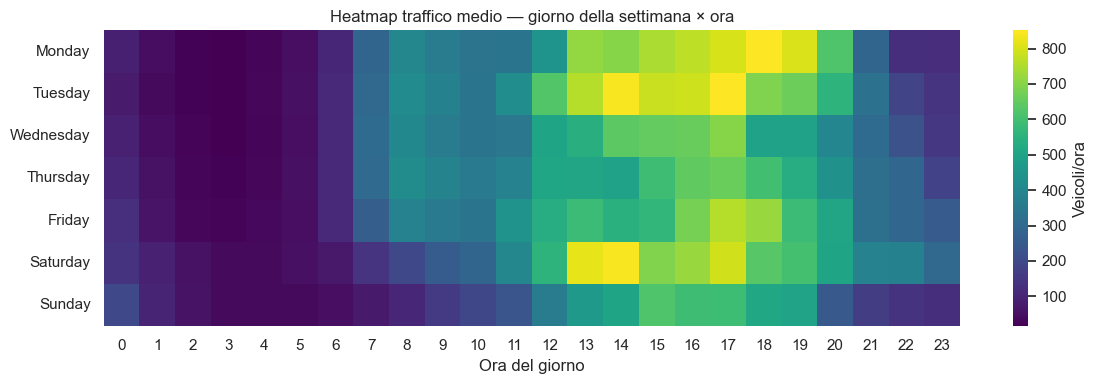

In [10]:
pivot = (
    df.groupby(['giorno_settimana', 'ora_del_giorno'])['conteggio_veicoli']
      .mean()
      .unstack()
      .reindex(ordine_giorni)
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': 'Veicoli/ora'}, ax=ax)
ax.set_title('Heatmap traffico medio — giorno della settimana × ora')
ax.set_xlabel('Ora del giorno')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 4.4 Traffico vs. pioggia

Un primo sguardo all'effetto del meteo: il flusso cambia quando piove?

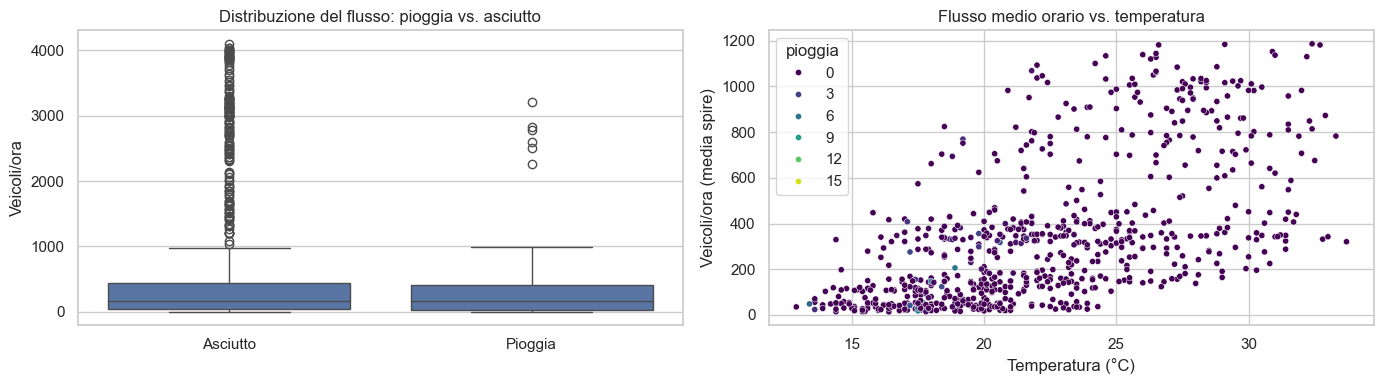

In [11]:
df['pioggia'] = df['precipitation'].fillna(0) > 0.1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) Boxplot: distribuzione del flusso con/senza pioggia
sns.boxplot(data=df, x='pioggia', y='conteggio_veicoli', ax=axes[0])
axes[0].set_title('Distribuzione del flusso: pioggia vs. asciutto')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Asciutto', 'Pioggia'])
axes[0].set_xlabel('')
axes[0].set_ylabel('Veicoli/ora')

# (b) Scatter: temperatura vs. flusso orario aggregato
agg = df.groupby('timestamp').agg(
    flusso=('conteggio_veicoli', 'mean'),
    temperatura=('temperature_2m', 'first'),
    pioggia=('precipitation', 'first'),
).reset_index()
sns.scatterplot(data=agg, x='temperatura', y='flusso', hue='pioggia',
                palette='viridis', s=20, ax=axes[1])
axes[1].set_title('Flusso medio orario vs. temperatura')
axes[1].set_xlabel('Temperatura (°C)')
axes[1].set_ylabel('Veicoli/ora (media spire)')

plt.tight_layout()
plt.show()

## 5. Dataset accuratezza spire

Il documento di progetto è chiaro: questo dataset *non è un dettaglio tecnico, è il cuore del progetto*. Permette di distinguere una spira rotta (accuratezza 0%) da una strada davvero vuota (accuratezza 100% con conteggio 0).

Schema simile al flusso ma con qualche differenza:
- chiavi rinominate (`data_2`, `codice_spira_2`)
- colonne orarie in formato `HH_00_HH` (3 segmenti invece di 4)
- valori in formato stringa `'85%'` da convertire in numerico
- per fare il join con il dataset principale si usa il campo `chiave` (presente in entrambi)


In [12]:
def scarica_accuratezza(anno: int, data_inizio: str, data_fine: str) -> pd.DataFrame:
    dataset_id = f'accuratezza-spire-anno-{anno}'
    url = f'https://opendata.comune.bologna.it/api/explore/v2.1/catalog/datasets/{dataset_id}/exports/json'
    params = {'where': f"data_2 >= '{data_inizio}' AND data_2 <= '{data_fine}'"}
    r = requests.get(url, params=params, timeout=120)
    r.raise_for_status()
    return pd.DataFrame(r.json())

file_acc = DATA_DIR / f'accuratezza_{DATA_INIZIO}_{DATA_FINE}.parquet'
if file_acc.exists():
    df_acc_raw = pd.read_parquet(file_acc)
    print(f'Letto da cache: {file_acc}')
else:
    df_acc_raw = scarica_accuratezza(ANNO, DATA_INIZIO, DATA_FINE)
    df_acc_raw.to_parquet(file_acc)
    print(f'Scaricato e salvato: {file_acc}')

print(f'Shape grezzo accuratezza: {df_acc_raw.shape}')
df_acc_raw.head(2)


Scaricato e salvato: data\accuratezza_2024-06-01_2024-06-30.parquet
Shape grezzo accuratezza: (27330, 27)


,data_2,codice_spira_2,00_00_01,01_00_02,02_00_03,03_00_04,04_00_05,05_00_06,06_00_07,07_00_08,...,15_00_16,16_00_17,17_00_18,18_00_19,19_00_20,20_00_21,21_00_22,22_00_23,23_00_24,chiave
0,2024-06-03,3.96 3.88 2 1,66%,66%,66%,66%,66%,66%,66%,66%,...,66%,66%,66%,15%,15%,-1%,-1%,15%,38%,687.0
1,2024-06-03,4.6 4.5 6 1,100%,100%,100%,100%,100%,100%,100%,100%,...,100%,100%,100%,100%,100%,100%,91%,100%,100%,845.0


In [13]:
# Le 'chiavi' delle spire selezionate sono direttamente nel df
chiavi_demo = df['chiave'].dropna().unique().tolist()
print(f'Chiavi accuratezza da filtrare: {chiavi_demo}')

df_acc_sel = df_acc_raw[df_acc_raw['chiave'].isin(chiavi_demo)].copy()

# Le colonne orarie qui sono HH_00_HH (3 segmenti)
pat_acc = re.compile(r'^\d{2}_\d{2}_\d{2}$')
colonne_orarie_acc = [c for c in df_acc_sel.columns if pat_acc.match(c)]
print(f'Colonne orarie accuratezza: {len(colonne_orarie_acc)}')

df_acc_long = df_acc_sel.melt(
    id_vars=['data_2', 'chiave'],
    value_vars=colonne_orarie_acc,
    var_name='fascia_oraria_acc',
    value_name='accuratezza_str',
)

df_acc_long['ora'] = df_acc_long['fascia_oraria_acc'].str[:2].astype(int)
df_acc_long['timestamp'] = (
    pd.to_datetime(df_acc_long['data_2']) + pd.to_timedelta(df_acc_long['ora'], unit='h')
)
df_acc_long['accuratezza'] = (
    df_acc_long['accuratezza_str'].astype(str).str.rstrip('%').replace('', np.nan).astype(float)
)
# Valori negativi (es. -1) sono un sentinel per 'dato mancante': li portiamo a NaN
df_acc_long.loc[df_acc_long['accuratezza'] < 0, 'accuratezza'] = np.nan

df_acc_long = df_acc_long[['chiave', 'timestamp', 'accuratezza']]
print(f'Shape accuratezza long: {df_acc_long.shape}')
df_acc_long.head()


Chiavi accuratezza da filtrare: [537, 538, 722, 800, 803]
Colonne orarie accuratezza: 24
Shape accuratezza long: (3600, 3)


,chiave,timestamp,accuratezza
0,537.0,2024-06-05,100.0
1,722.0,2024-06-06,100.0
2,803.0,2024-06-06,50.0
3,537.0,2024-06-06,100.0
4,800.0,2024-06-06,100.0


In [14]:
# La 'chiave' e' gia' nel df (impostata nella selezione iniziale), il merge e' diretto
df = df.merge(df_acc_long, on=['chiave', 'timestamp'], how='left')

print(f'Shape dopo merge accuratezza: {df.shape}')
print(
    f"Accuratezza: media={df['accuratezza'].mean():.1f}%  "
    f"min={df['accuratezza'].min():.0f}%  NaN={df['accuratezza'].isna().sum()}"
)
df[['timestamp', 'id_uni', 'chiave', 'conteggio_veicoli', 'accuratezza']].head()


Shape dopo merge accuratezza: (3600, 22)
Accuratezza: media=85.2%  min=0%  NaN=0


,timestamp,id_uni,chiave,conteggio_veicoli,accuratezza
0,2024-06-01 00:00:00,1,537,168,100.0
1,2024-06-01 01:00:00,1,537,125,100.0
2,2024-06-01 02:00:00,1,537,101,100.0
3,2024-06-01 03:00:00,1,537,67,100.0
4,2024-06-01 04:00:00,1,537,77,100.0


## 6. Calendario festività italiane

Usiamo il pacchetto `holidays` (`pip install holidays`) che conosce le festività nazionali italiane. Aggiungiamo anche due colonne derivate utili per il problem framing: `tipo_giorno` (feriale / weekend / festivo) e `festa_locale` per la festa di San Petronio (4 ottobre), che `holidays` non include di default.


In [15]:
import holidays

anni = sorted(df['timestamp'].dt.year.unique().tolist())
festivita_it = holidays.country_holidays('IT', years=anni)

# Festività locali bolognesi (esempio minimale)
festivita_locali = {f'{a}-10-04': 'San Petronio' for a in anni}

df['data_giorno']       = df['timestamp'].dt.date
df['festivo_nazionale'] = df['data_giorno'].apply(lambda d: d in festivita_it)
df['nome_festivita']    = df['data_giorno'].apply(lambda d: festivita_it.get(d))
df['festa_locale']      = df['timestamp'].dt.strftime('%Y-%m-%d').map(festivita_locali).notna()

def categoria_giorno(row):
    if row['festivo_nazionale'] or row['festa_locale']:
        return 'festivo'
    if row['weekend']:
        return 'weekend'
    return 'feriale'

df['tipo_giorno'] = df.apply(categoria_giorno, axis=1)

print('Distribuzione tipi giorno (ore):')
print(df['tipo_giorno'].value_counts())
print()
print('Festività trovate nel periodo:')
fest = df.loc[df['festivo_nazionale'], ['data_giorno', 'nome_festivita']].drop_duplicates()
if len(fest):
    print(fest.to_string(index=False))
else:
    print('(nessuna nel periodo selezionato)')


Distribuzione tipi giorno (ore):
tipo_giorno
feriale    2400
weekend    1080
festivo     120
Name: count, dtype: int64

Festività trovate nel periodo:
data_giorno         nome_festivita
 2024-06-02 Festa della Repubblica


## 7. Visualizzazioni con i nuovi dati

### 7.1 Heatmap accuratezza spire

Una vista d'insieme di quanto sono affidabili le misure ora-per-ora nel periodo. Le zone scure sono quelle dove il sensore ha funzionato male: è esattamente lì che il sistema di anomaly detection rischia di generare falsi positivi se non si gestisce la qualità del dato.

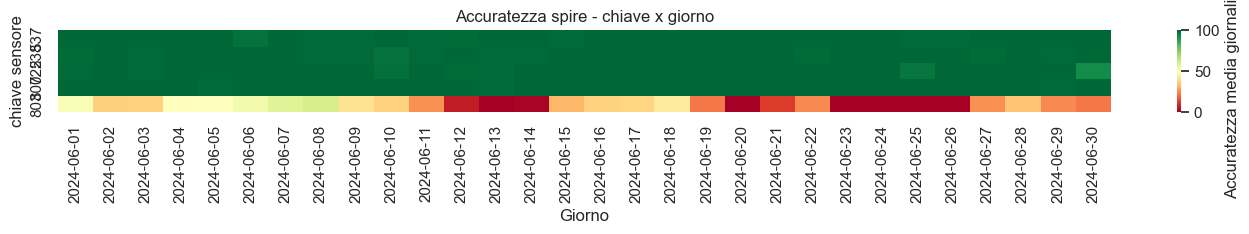

In [16]:
acc_pivot = (
    df.assign(giorno=df['timestamp'].dt.date)
      .groupby(['chiave', 'giorno'])['accuratezza']
      .mean()
      .unstack()
)

fig, ax = plt.subplots(figsize=(14, max(2, len(acc_pivot) * 0.5)))
sns.heatmap(acc_pivot, cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Accuratezza media giornaliera (%)'}, ax=ax)
ax.set_title('Accuratezza spire - chiave x giorno')
ax.set_xlabel('Giorno')
ax.set_ylabel('chiave sensore')
plt.tight_layout()
plt.show()


### 7.2 Profilo orario: feriali vs weekend vs festivi

Aspettativa: festivi e weekend dovrebbero schiacciare la doppia gobba delle ore di punta. Se così non fosse su una determinata spira, è già un'informazione interessante per il problem framing.

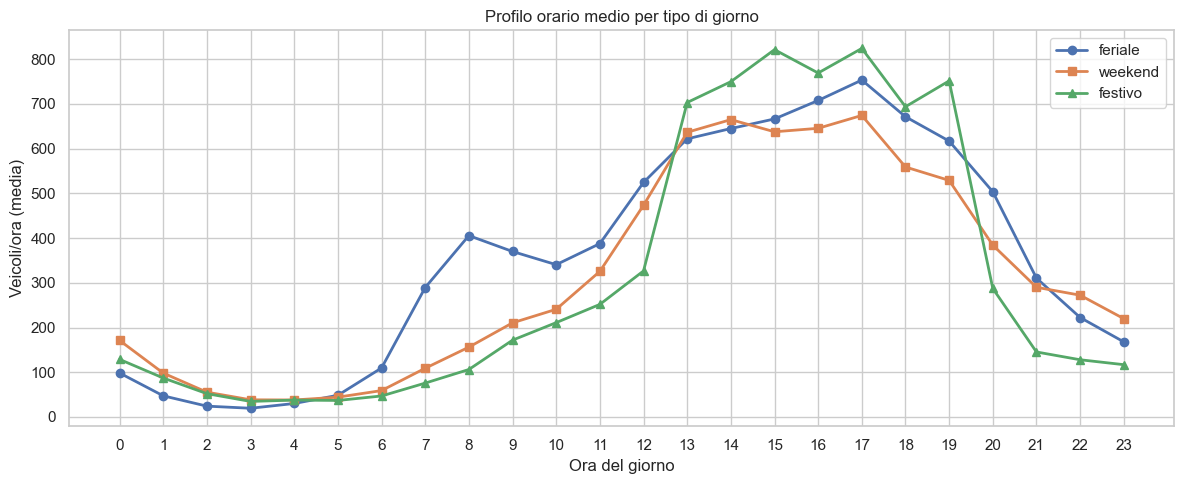

In [17]:
profilo_g = (
    df.groupby(['tipo_giorno', 'ora_del_giorno'])['conteggio_veicoli']
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for tipo, marker in zip(['feriale', 'weekend', 'festivo'], ['o', 's', '^']):
    sub = profilo_g[profilo_g['tipo_giorno'] == tipo]
    if not sub.empty:
        ax.plot(sub['ora_del_giorno'], sub['conteggio_veicoli'],
                marker=marker, label=tipo, linewidth=2)
ax.set_title('Profilo orario medio per tipo di giorno')
ax.set_xlabel('Ora del giorno')
ax.set_ylabel('Veicoli/ora (media)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()


### 7.3 Tempo atmosferico → conteggio veicoli

Quale 'tipo di tempo' coincide mediamente con più o meno traffico? Attenzione: in un solo mese alcune categorie possono avere pochissime ore — interpretare con cautela.

                              mean  count
tempo                                    
Pioggia intensa          65.933333     15
Pioggia moderata        164.700000     60
Pioggerella moderata    285.369231     65
Pioggia leggera         295.820000     50
Pioggerella intensa     308.266667     15
Coperto                 310.780645    775
Sereno                  318.100709   1410
Parzialmente nuvoloso   376.402597    385
Pioggerella leggera     399.188235    340
Prevalentemente sereno  446.063918    485


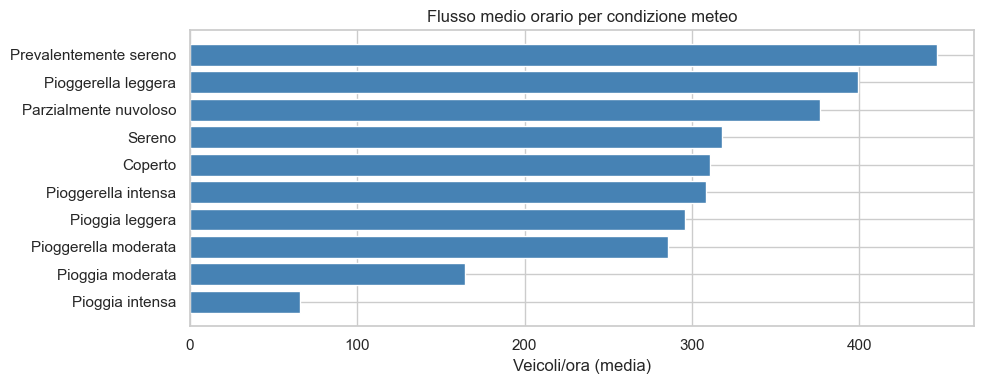

In [18]:
conteggio_per_tempo = (
    df.groupby('tempo')['conteggio_veicoli']
      .agg(['mean', 'count'])
      .sort_values('mean', ascending=True)
)
print(conteggio_per_tempo)

fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(conteggio_per_tempo))))
ax.barh(conteggio_per_tempo.index, conteggio_per_tempo['mean'], color='steelblue')
ax.set_xlabel('Veicoli/ora (media)')
ax.set_title('Flusso medio orario per condizione meteo')
plt.tight_layout()
plt.show()


## Prossimi passi (non in questa demo)

Quanto coperto qui — download dati, merge, accuratezza, festività, prime viz — è la base operativa. Da qui parte il progetto vero:

- **Fase 1 — Problem framing**: definizione operativa di anomalia, tipi che il sistema deve / non deve catturare, utente finale, asimmetria FP/FN.
- **Fase 2 — Tre baseline** di anomaly detection:
  - statistica classica (STL + soglia su residui via MAD)
  - density-based (IsolationForest / LOF con feature engineered)
  - forecasting-based (gradient boosting con lag + meteo come feature)
- **Fase 3 — Protocollo di valutazione** senza etichette: iniezione di anomalie sintetiche, validazione con eventi reali (15-20 eventi storici), analisi di stabilità al variare degli iperparametri, metriche custom coerenti col framing.
- **Fase 4 — Reporting** e codice riproducibile.

Tutto il dettaglio è nel documento di progetto.
